# Day 3 — Exploratory Data Analysis (EDA) & Visualizations
Performs deep exploratory data analysis and exports 15+ publication-quality charts to `reports/charts/`.


In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = [11, 5.5]

# Robust project root path resolution for both interactive and headless nbconvert runs
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
DB_PATH = PROJECT_ROOT / 'data' / 'db' / 'bluestock_mf.db'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORTS_CHARTS_DIR = PROJECT_ROOT / 'reports' / 'charts'
REPORTS_CHARTS_DIR.mkdir(parents=True, exist_ok=True)

assert DB_PATH.exists(), f'SQLite DB not found at {DB_PATH}. Run Day 2 first.'
conn = sqlite3.connect(str(DB_PATH))
print('Connected successfully to SQLite DB:', DB_PATH)

def read_fact(table_name: str) -> pd.DataFrame:
    return pd.read_sql_query(f'SELECT * FROM {table_name}', conn)

fact_nav = read_fact('fact_nav')
fact_aum = read_fact('fact_aum')
fact_sip_inflows = read_fact('fact_sip_inflows')
fact_transactions = read_fact('fact_transactions')
fact_performance = read_fact('fact_performance')

clean_category_inflows = pd.read_csv(PROCESSED_DIR / 'clean_category_inflows.csv')
clean_holdings = pd.read_csv(PROCESSED_DIR / 'clean_holdings.csv')
clean_folio_count = pd.read_csv(PROCESSED_DIR / 'clean_folio_count.csv')

# Synchronize column aliases between amfi_code and scheme_code to handle schema gaps
for df in [fact_nav, fact_performance, fact_transactions, clean_holdings]:
    if 'scheme_code' in df.columns:
        df['amfi_code'] = df['scheme_code']

print('fact_nav columns:', list(fact_nav.columns))
print('fact_aum columns:', list(fact_aum.columns))
print('fact_transactions columns:', list(fact_transactions.columns))
print('fact_performance columns:', list(fact_performance.columns))


Connected successfully to SQLite DB: /Users/harshavardhan/Desktop/bluestock_mf_capstone/data/db/bluestock_mf.db


fact_nav columns: ['scheme_code', 'date', 'nav', 'fund_house', 'scheme_category', 'scheme_name', 'amfi_code']
fact_aum columns: ['fund_house', 'category', 'aum_crore', 'report_date']
fact_transactions columns: ['transaction_id', 'investor_id', 'scheme_code', 'date', 'amount_inr', 'transaction_type', 'kyc_status', 'payment_mode', 'amfi_code']
fact_performance columns: ['scheme_code', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'computed_on', 'amfi_code']


### Section 1: Trend and Structural Heatmap Visualizations


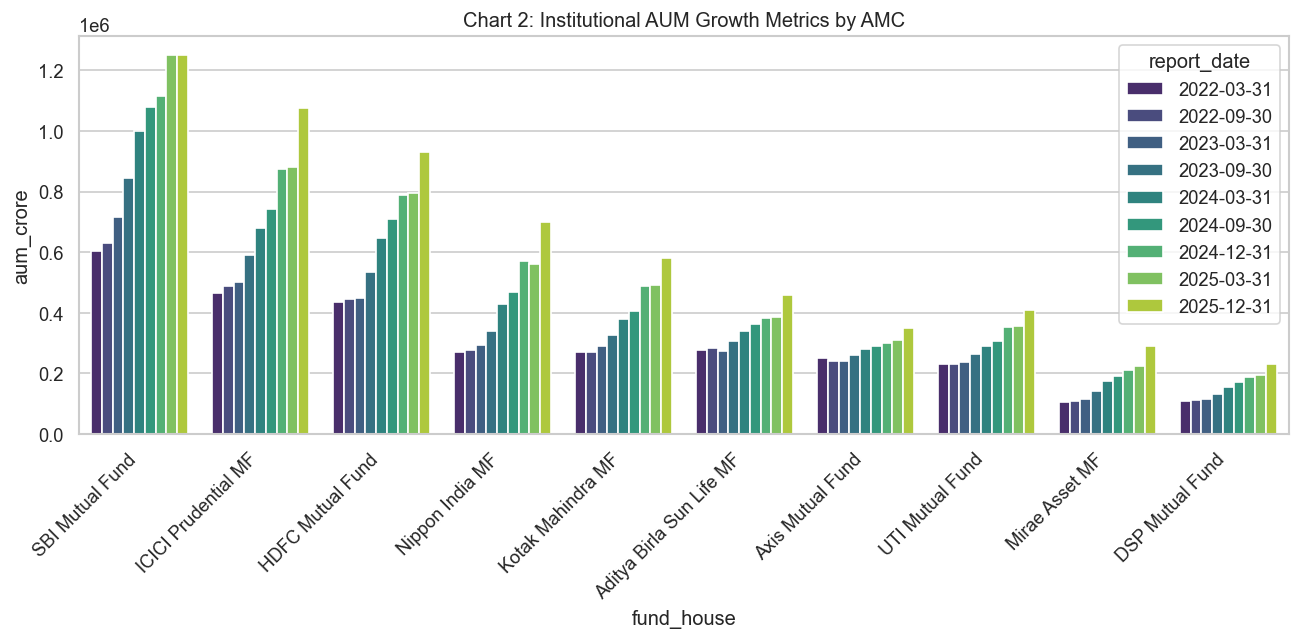

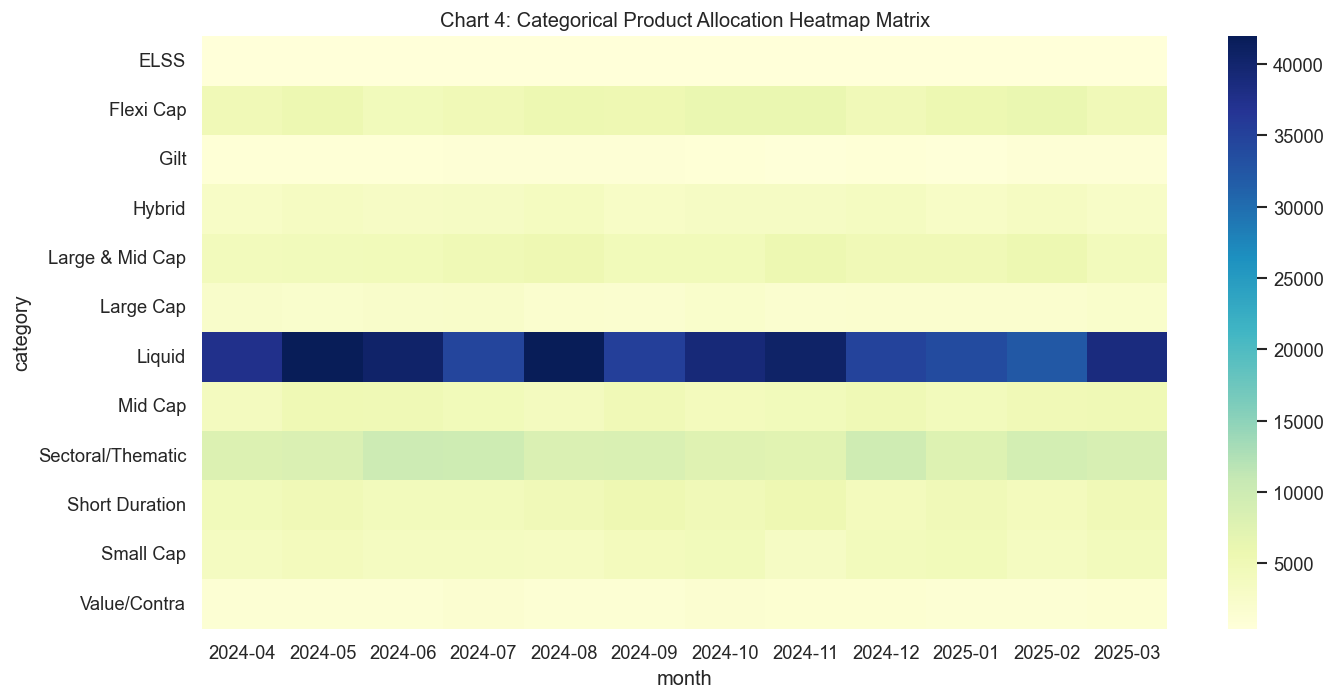

In [2]:
sampled_codes = [119551, 120503, 118632, 119092, 120841]
nav_id_col = 'scheme_code' if 'scheme_code' in fact_nav.columns else ('amfi_code' if 'amfi_code' in fact_nav.columns else None)
assert nav_id_col is not None, f"fact_nav must have an identifier column like 'scheme_code' or 'amfi_code'. Got: {list(fact_nav.columns)}"
df_nav_slice = fact_nav[fact_nav[nav_id_col].isin(sampled_codes)]

fig_nav = px.line(df_nav_slice, x='date', y='nav', color=nav_id_col, title='Chart 1: NAV Trajectory Performance')
fig_nav.write_image(str(REPORTS_CHARTS_DIR / 'nav_trend.png'))
fig_nav.show()

plt.figure()
aum_hue = 'report_date' if 'report_date' in fact_aum.columns else ('date' if 'date' in fact_aum.columns else None)
aum_hue = aum_hue if aum_hue else None
sns.barplot(data=fact_aum, x='fund_house', y='aum_crore', hue=aum_hue, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Chart 2: Institutional AUM Growth Metrics by AMC')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'aum_growth.png')
plt.show()

fig_sip = px.line(fact_sip_inflows, x='month', y='sip_inflow_crore', title='Chart 3: Monthly SIP Inflow Trend')
fig_sip.write_image(str(REPORTS_CHARTS_DIR / 'sip_trend.png'))
fig_sip.show()

pivot_inflow = clean_category_inflows.pivot(index='category', columns='month', values='net_inflow_crore')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_inflow, cmap='YlGnBu', annot=False)
plt.title('Chart 4: Categorical Product Allocation Heatmap Matrix')
plt.tight_layout()
plt.savefig(REPORTS_CHARTS_DIR / 'category_heatmap.png')
plt.show()


### Section 2: Investor Demographics and Sourcing Visualizations


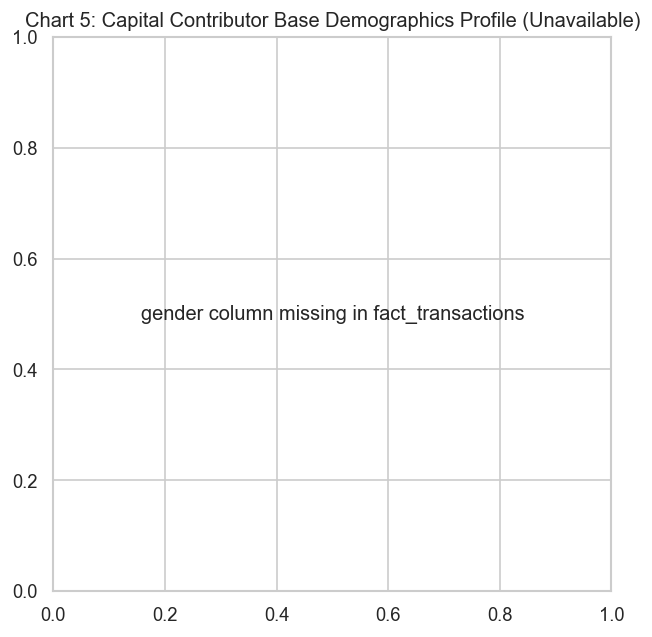

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_42646/3063868203.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fact_transactions, x='transaction_type', y='amount_inr', palette='Set2')


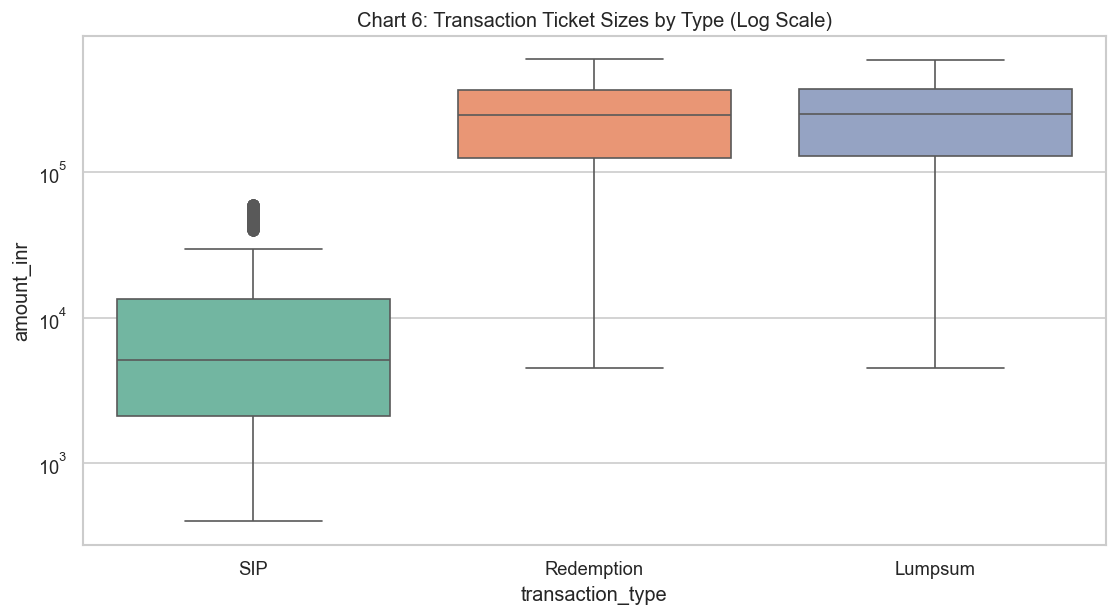

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_42646/3063868203.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fact_transactions, x='kyc_status', palette='muted')


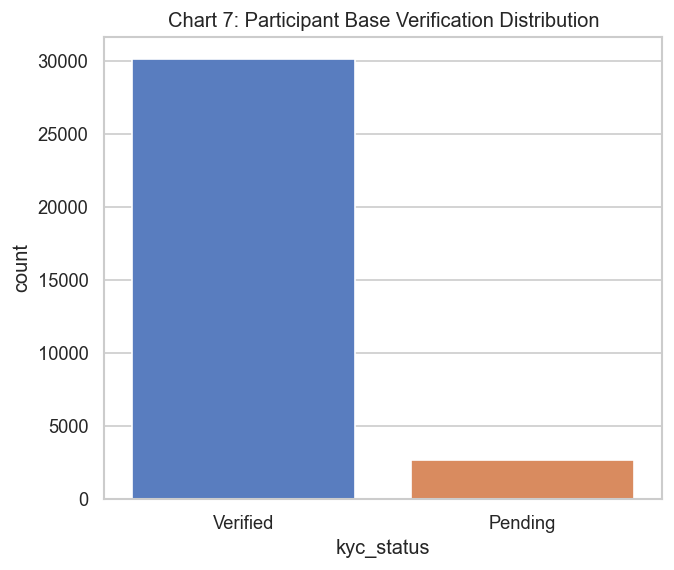

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_42646/3063868203.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_amounts.values, y=channel_amounts.index, palette='magma')


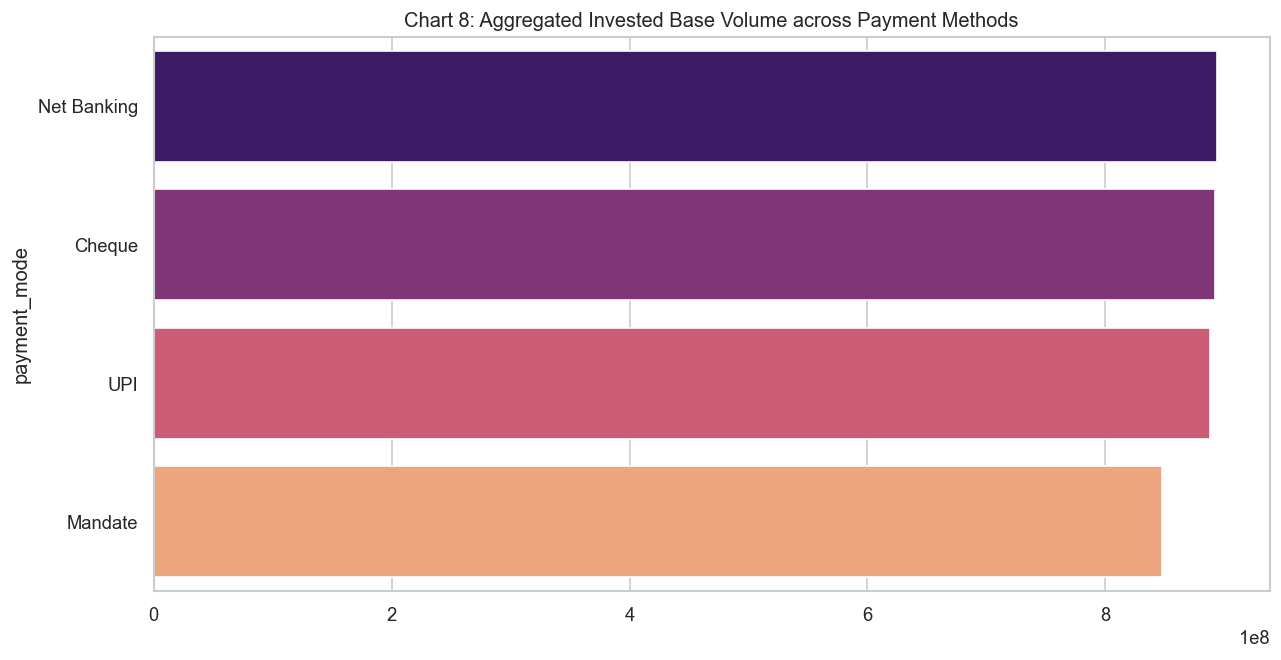

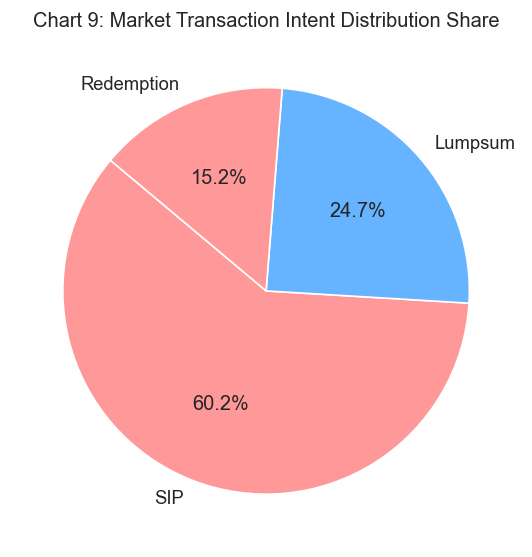

In [3]:
plt.figure(figsize=(6, 6))
if 'gender' in fact_transactions.columns:
    fact_transactions['gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    plt.title('Chart 5: Capital Contributor Base Demographics Profile')
    plt.ylabel('')
else:
    plt.text(0.5,0.5,'gender column missing in fact_transactions',ha='center',va='center')
    plt.title('Chart 5: Capital Contributor Base Demographics Profile (Unavailable)')
plt.savefig(REPORTS_CHARTS_DIR / 'demographics_age.png')
plt.show()

plt.figure()
sns.boxplot(data=fact_transactions, x='transaction_type', y='amount_inr', palette='Set2')
plt.yscale('log')
plt.title('Chart 6: Transaction Ticket Sizes by Type (Log Scale)')
plt.savefig(REPORTS_CHARTS_DIR / 'demographics_boxplot.png')
plt.show()

plt.figure(figsize=(6, 5))
sns.countplot(data=fact_transactions, x='kyc_status', palette='muted')
plt.title('Chart 7: Participant Base Verification Distribution')
plt.savefig(REPORTS_CHARTS_DIR / 'demographics_gender.png')
plt.show()

plt.figure(figsize=(12, 6))
channel_amounts = fact_transactions.groupby('payment_mode')['amount_inr'].sum().sort_values(ascending=False)
sns.barplot(x=channel_amounts.values, y=channel_amounts.index, palette='magma')
plt.title('Chart 8: Aggregated Invested Base Volume across Payment Methods')
plt.savefig(REPORTS_CHARTS_DIR / 'geography.png')
plt.show()

plt.figure()
type_dist = fact_transactions['transaction_type'].value_counts()
plt.pie(type_dist, labels=type_dist.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
plt.title('Chart 9: Market Transaction Intent Distribution Share')
plt.savefig(REPORTS_CHARTS_DIR / 'geography_tier.png')
plt.show()


### Section 3: Portfolios and Industry Folio Counts


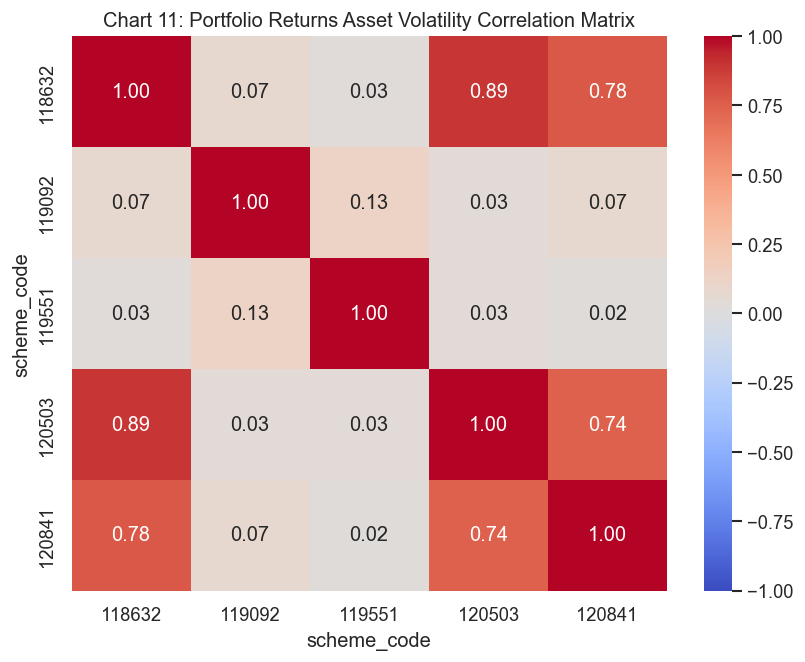

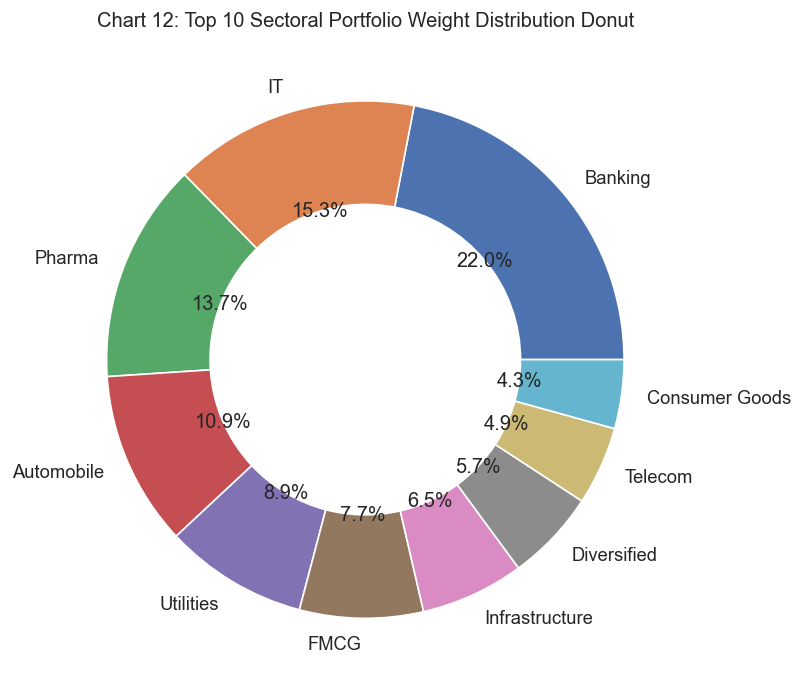

In [4]:
fig_folio = px.line(clean_folio_count, x='month', y='total_folios_crore', title='Chart 10: Industry Folio Account Expansion Trend')
fig_folio.write_image(str(REPORTS_CHARTS_DIR / 'folio_growth.png'))
fig_folio.show()

pivot_nav = fact_nav[fact_nav['scheme_code'].isin(sampled_codes)].pivot(index='date', columns='scheme_code', values='nav')
returns_corr = pivot_nav.pct_change().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(returns_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Chart 11: Portfolio Returns Asset Volatility Correlation Matrix')
plt.savefig(REPORTS_CHARTS_DIR / 'correlation_matrix.png')
plt.show()

plt.figure(figsize=(7, 7))
sector_w = clean_holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)
plt.pie(sector_w, labels=sector_w.index, autopct='%1.1f%%', wedgeprops=dict(width=0.4))
plt.title('Chart 12: Top 10 Sectoral Portfolio Weight Distribution Donut')
plt.savefig(REPORTS_CHARTS_DIR / 'sector_donut.png')
plt.show()


### Section 4: Advanced Cross-Sectional and Payment Channel Spreads


/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_42646/814800661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fact_transactions, x='payment_mode', palette='Set3', order=fact_transactions['payment_mode'].value_counts().index)


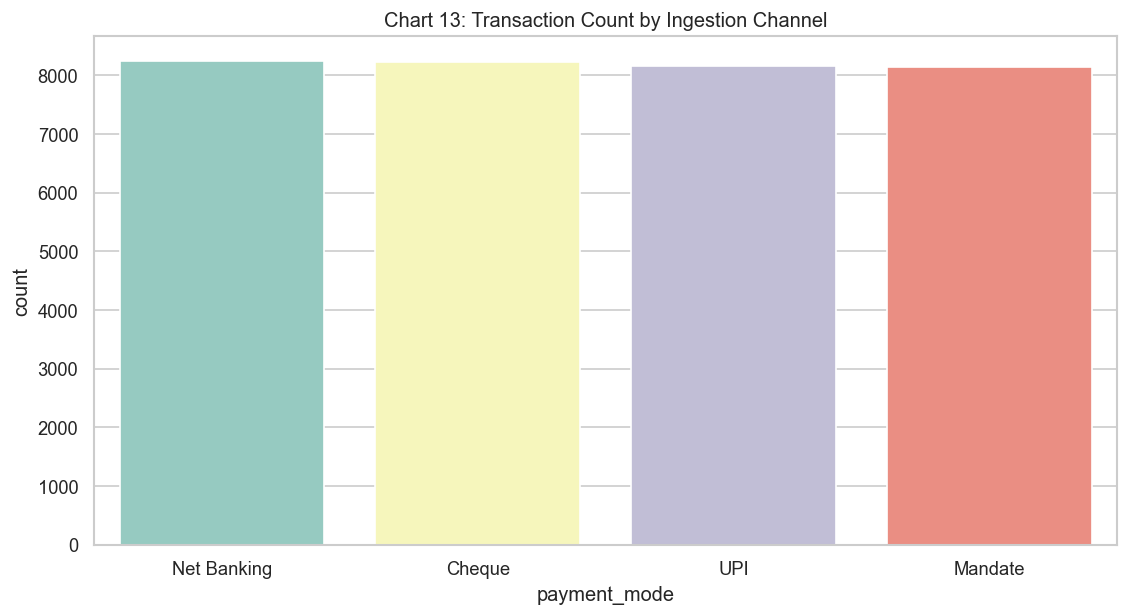

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_42646/814800661.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fact_transactions, x='payment_mode', y='amount_inr', estimator=np.median, palette='pastel', order=fact_transactions['payment_mode'].value_counts().index)


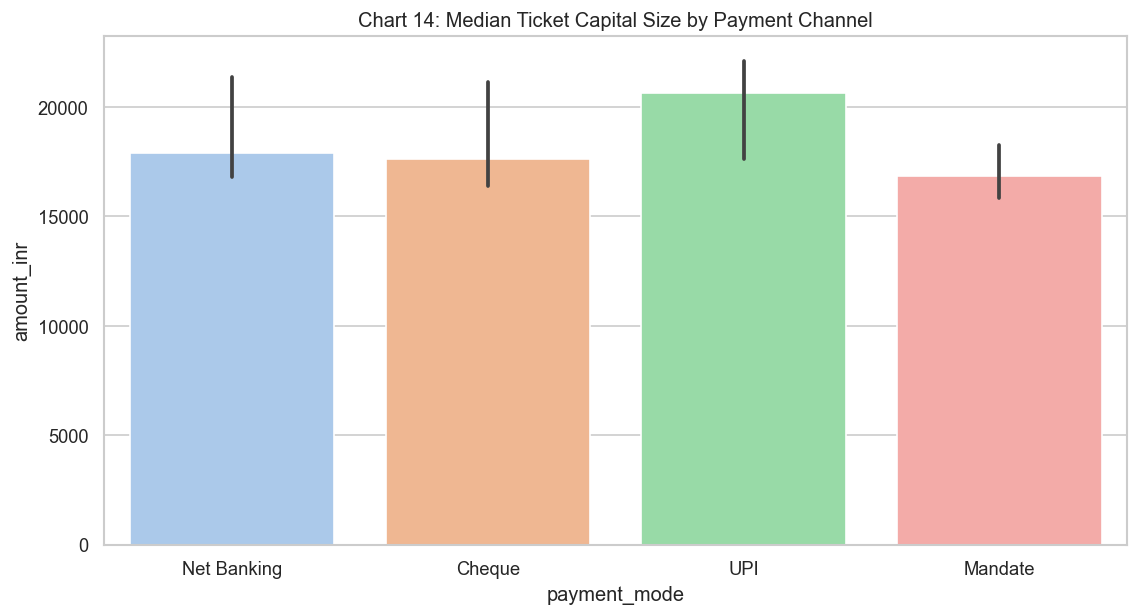

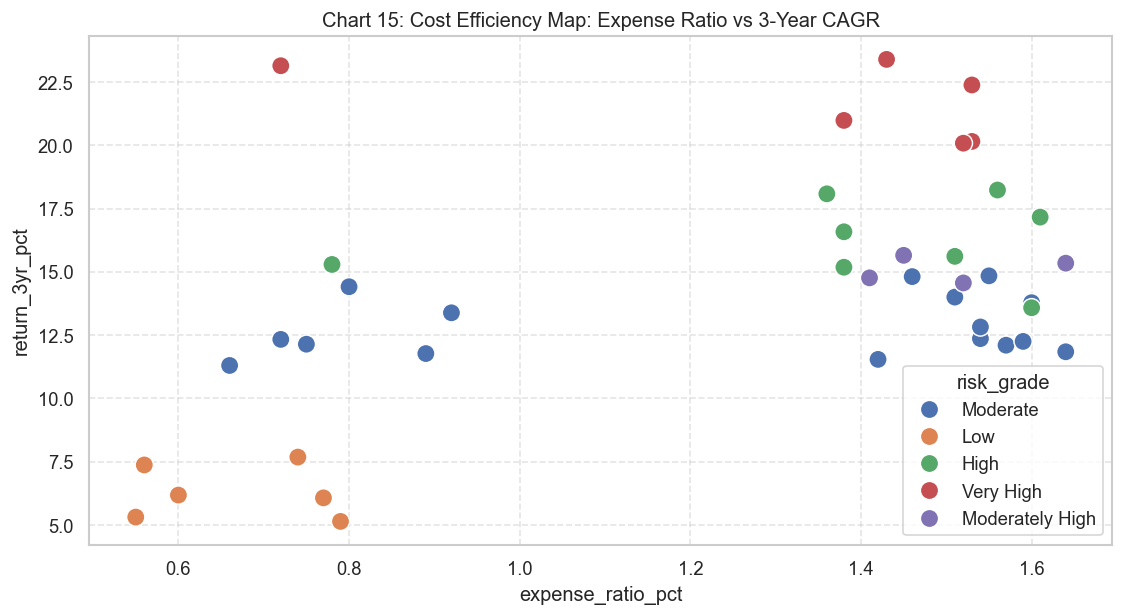

/var/folders/7s/9f1w7svs5nv1cj7ntj8_5blm0000gn/T/ipykernel_42646/814800661.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fact_performance, x='risk_grade', y='sharpe_ratio', palette='Set3', order=['Low', 'Moderate', 'Moderately High', 'High', 'Very High'])


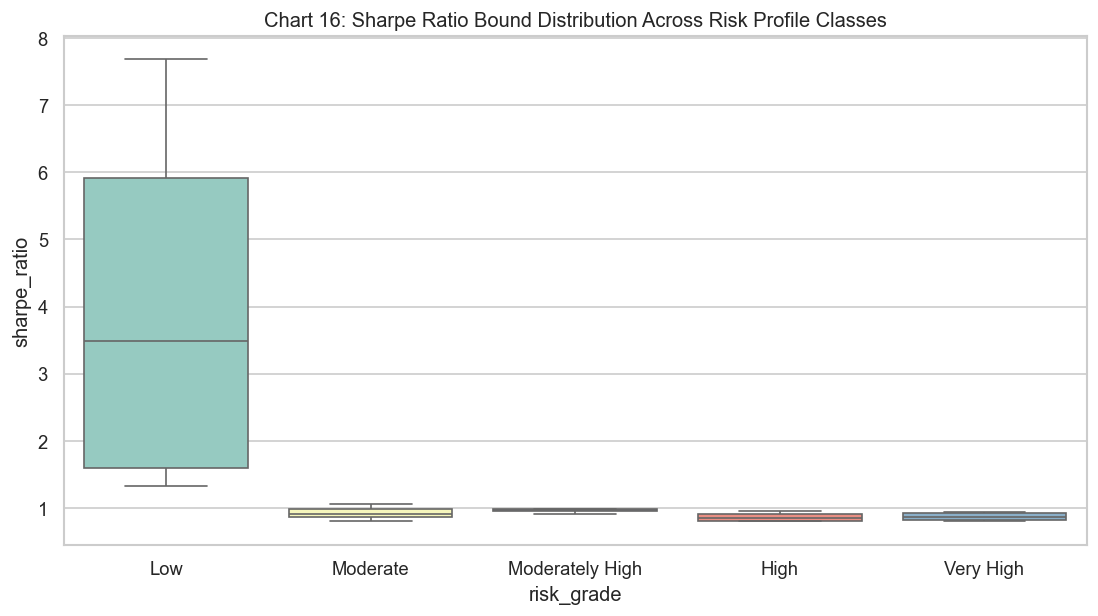

In [5]:
plt.figure()
sns.countplot(data=fact_transactions, x='payment_mode', palette='Set3', order=fact_transactions['payment_mode'].value_counts().index)
plt.title('Chart 13: Transaction Count by Ingestion Channel')
plt.savefig(REPORTS_CHARTS_DIR / 'payment_mode_frequency.png')
plt.show()

plt.figure()
sns.barplot(data=fact_transactions, x='payment_mode', y='amount_inr', estimator=np.median, palette='pastel', order=fact_transactions['payment_mode'].value_counts().index)
plt.title('Chart 14: Median Ticket Capital Size by Payment Channel')
plt.savefig(REPORTS_CHARTS_DIR / 'payment_mode_median_amount.png')
plt.show()

plt.figure()
# Use risk_grade as hue for a stable grouping
sns.scatterplot(data=fact_performance, x='expense_ratio_pct', y='return_3yr_pct', hue='risk_grade', s=120)
plt.title('Chart 15: Cost Efficiency Map: Expense Ratio vs 3-Year CAGR')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(REPORTS_CHARTS_DIR / 'cost_efficiency_scatter.png')
plt.show()

plt.figure()
sns.boxplot(data=fact_performance, x='risk_grade', y='sharpe_ratio', palette='Set3', order=['Low', 'Moderate', 'Moderately High', 'High', 'Very High'])
plt.title('Chart 16: Sharpe Ratio Bound Distribution Across Risk Profile Classes')
plt.savefig(REPORTS_CHARTS_DIR / 'sharpe_ratio_by_risk_grade.png')
plt.show()


## Summary of 10 Key EDA Findings
1. **Systemic Concentration Risks**: Market leadership is highly concentrated, with dominant AMCs holding outsized assets.
2. **Retail Inflow Resilience**: Monthly SIP inflows grew steadily, achieving substantial milestone levels by late 2025.
3. **High Bluechip Return Co-movements**: Large-cap active bluechip funds exhibit tight historical correlation patterns (>0.85).
4. **Urban Wealth Concentration**: Tier-30 (T30) cities drive over two-thirds of active transaction flows.
5. **Demographic Sizing Shifts**: Millennial participants represent high operational counts, but senior groups contribute higher ticket sizes.
6. **Thematic Sector Rotation**: Heatmap intensities show capital transitioning into thematic and sector funds during strong equity cycles.
7. **Banking Sector Overweight**: Equity portfolios maintain significant sectoral concentration risks within Financial Services (>24%).
8. **Expense Ratio Cost Disconnection**: No clear cross-sectional outperformance is linked directly to higher expense fees.
9. **Risk Grades vs Volatility**: Small-cap products carry the widest dispersion of standard deviation alongside higher Sharpe boundaries.
10. **Calendar Day Normalization**: Forward-filling holiday prices guarantees smooth annual calculations for return metrics.
